In [3]:
import pandas as pd
import numpy as np
import yfinance as yf
import plotly.offline as pyo
import plotly.graph_objects as go

from plotly.subplots import make_subplots

pyo.init_notebook_mode(connected=True)
pd.options.plotting.backend = 'plotly'

In [5]:
df = yf.download(['TCS.NS', 'INFY.NS', 'WIPRO.NS', 'HCLTECH.NS', 'TECHM.NS', '^CNXIT'], start='2005-01-01')
df

[*********************100%***********************]  6 of 6 completed


Price             Close                                                     \
Ticker       HCLTECH.NS      INFY.NS       TCS.NS     TECHM.NS    WIPRO.NS   
Date                                                                         
2005-01-03    25.182713    84.667336   110.342491          NaN   33.039146   
2005-01-04    25.002729    83.488930   109.364059          NaN   32.813545   
2005-01-05    24.107164    81.988968   108.038239          NaN   30.984604   
2005-01-06    23.171261    81.639442   107.668022          NaN   30.200464   
2005-01-07    23.498106    81.921082   109.257996          NaN   30.653870   
...                 ...          ...          ...          ...         ...   
2026-02-04  1621.800049  1535.800049  2999.100098  1645.300049  233.339996   
2026-02-05  1610.000000  1520.199951  2991.500000  1646.199951  233.389999   
2026-02-06  1593.699951  1507.099976  2941.600098  1619.900024  230.720001   
2026-02-09  1602.000000  1497.199951  2948.199951  1621.699951  230.080002   
2026-02-10  1599.400024  1501.800049  2976.000000  1649.400024  230.050003   

Price                            High                                         \
Ticker            ^CNXIT   HCLTECH.NS      INFY.NS       TCS.NS     TECHM.NS   
Date                                                                           
2005-01-03           NaN    25.269104    95.790270   110.622978          NaN   
2005-01-04           NaN    25.341091    84.885037   110.402857          NaN   
2005-01-05           NaN    25.053137    83.087480   109.277617          NaN   
2005-01-06           NaN    24.477192    83.644725   109.750513          NaN   
2005-01-07           NaN    23.742878    82.488312   109.668952          NaN   
...                  ...          ...          ...          ...          ...   
2026-02-04  36345.648438  1645.000000  1584.900024  3120.000000  1656.000000   
2026-02-05  36143.300781  1631.800049  1551.000000  3029.699951  1659.099976   
2026-02-06  35611.050781  1612.000000  1525.000000  2985.000000  1645.900024   
2026-02-09  35616.648438  1619.900024  1528.000000  2977.000000  1636.000000   
2026-02-10  35821.050781  1601.000000  1505.500000  2983.000000  1657.300049   

Price       ...         Open                                         \
Ticker      ...       TCS.NS     TECHM.NS    WIPRO.NS        ^CNXIT   
Date        ...                                                       
2005-01-03  ...   108.891106          NaN   33.074193           NaN   
2005-01-04  ...   110.076703          NaN   33.074198           NaN   
2005-01-05  ...   109.277617          NaN   32.592318           NaN   
2005-01-06  ...   107.630518          NaN   30.971464           NaN   
2005-01-07  ...   108.445878          NaN   30.226751           NaN   
...         ...          ...          ...         ...           ...   
2026-02-04  ...  3120.000000  1651.000000  235.910004  37165.351562   
2026-02-05  ...  2990.000000  1630.099976  233.339996  36215.648438   
2026-02-06  ...  2976.600098  1645.000000  232.929993  36079.851562   
2026-02-09  ...  2959.100098  1625.000000  231.850006  35840.898438   
2026-02-10  ...  2949.800049  1625.000000  229.979996  35656.949219   

Price          Volume                                                          
Ticker     HCLTECH.NS     INFY.NS      TCS.NS   TECHM.NS    WIPRO.NS   ^CNXIT  
Date                                                                           
2005-01-03    2597488   9104288.0   4734168.0        NaN   7628977.0      NaN  
2005-01-04    1814080  10220864.0   4979104.0        NaN   7618292.0      NaN  
2005-01-05    1800952  22197872.0   9604320.0        NaN  26921936.0      NaN  
2005-01-06    3705416  27031104.0   8006888.0        NaN  24126398.0      NaN  
2005-01-07    1883800  33500080.0   7623136.0        NaN  13164106.0      NaN  
...               ...         ...         ...        ...         ...      ...  
2026-02-04    5834470  28828622.0  10852595.0  4823180.0  25995324.0  8

In [11]:
df.Close.dropna()

Ticker,HCLTECH.NS,INFY.NS,TCS.NS,TECHM.NS,WIPRO.NS,^CNXIT
Date,,,,,,
2007-09-17,43.332047,147.795670,167.336121,219.116867,40.472408,4573.549805
2007-09-18,43.768559,147.775208,168.141266,219.456543,40.004097,4576.750000
2007-09-19,44.298599,151.628174,171.596497,230.248123,40.386845,4667.299805
2007-09-20,42.950100,147.435425,168.074158,220.696106,39.148552,4566.049805
2007-09-21,42.989067,149.523605,170.715897,217.792343,39.508781,4603.850098
...,...,...,...,...,...,...
2026-02-04,1621.800049,1535.800049,2999.100098,1645.300049,233.339996,36345.648438
2026-02-05,1610.000000,1520.199951,2991.500000,1646.199951,233.389999,36143.300781
2026-02-06,1593.699951,1507.099976,2941.600098,1619.900024,230.720001,35611.050781


In [15]:
log_returns = np.log(df.Close/df.Close.shift(1)).dropna()
log_returns

Ticker,HCLTECH.NS,INFY.NS,TCS.NS,TECHM.NS,WIPRO.NS,^CNXIT
Date,,,,,,
2007-09-18,0.010023,-0.000138,0.004800,0.001549,-0.011639,0.000699
2007-09-19,0.012037,0.025739,0.020341,0.048003,0.009522,0.019592
2007-09-20,-0.030914,-0.028041,-0.020740,-0.042371,-0.031141,-0.021932
2007-09-21,0.000907,0.014064,0.015595,-0.013245,0.009160,0.008244
2007-09-24,0.011359,-0.035028,-0.010420,-0.011409,0.010431,-0.009515
...,...,...,...,...,...,...
2026-02-04,-0.044323,-0.075354,-0.072714,-0.042365,-0.039288,-0.060482
2026-02-05,-0.007302,-0.010210,-0.002537,0.000547,0.000214,-0.005583
2026-02-06,-0.010176,-0.008655,-0.016821,-0.016105,-0.011506,-0.014836


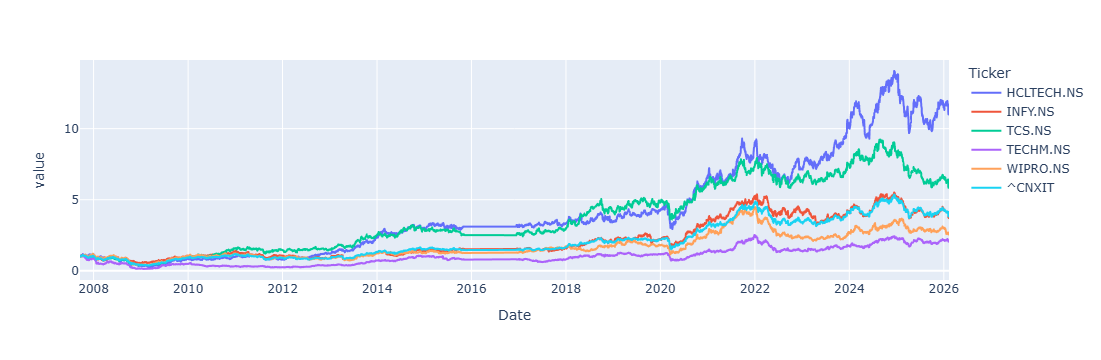

In [17]:
daily_cum_returns = (log_returns + 1).cumprod()
daily_cum_returns.plot()

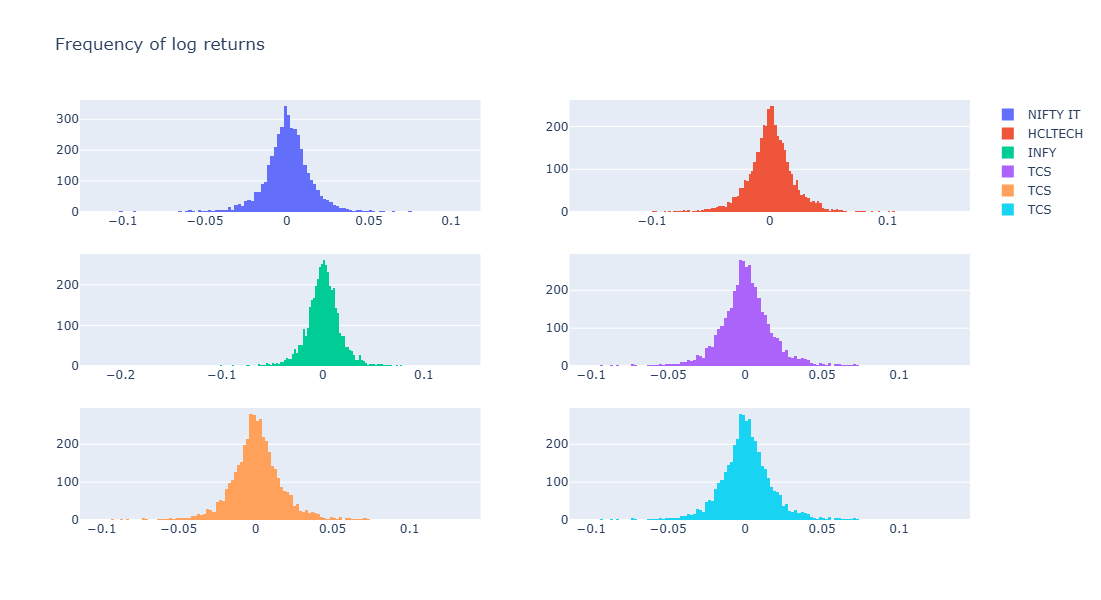

In [23]:
fig = make_subplots(rows=3, cols=2)

img0 = go.Histogram(x=log_returns['^CNXIT'], name='NIFTY IT')
img1 = go.Histogram(x=log_returns['HCLTECH.NS'], name='HCLTECH')
img2 = go.Histogram(x=log_returns['INFY.NS'], name='INFY')
img3 = go.Histogram(x=log_returns['TCS.NS'], name='TCS')
img4 = go.Histogram(x=log_returns['TECHM.NS'], name='TECHM')
img5 = go.Histogram(x=log_returns['WIPRO.NS'], name='WIPRO')

fig.append_trace(img0, 1, 1)  #This is in terms of rows and columns
fig.append_trace(img1, 1, 2)
fig.append_trace(img2, 2, 1)
fig.append_trace(img3, 2, 2)
fig.append_trace(img3, 3, 1)
fig.append_trace(img3, 3, 2)

fig.update_layout(autosize=False, width=1100, height=600, title='Frequency of log returns')

fig.show()

# Daily Standard Deviation

In [25]:
daily_std = log_returns.std()
daily_std

Ticker
HCLTECH.NS    0.021589
INFY.NS       0.018907
TCS.NS        0.018479
TECHM.NS      0.022950
WIPRO.NS      0.019479
^CNXIT        0.015668
dtype: float64

# Annualized Volatility

In [27]:
annualized_volatility = daily_std * np.sqrt(252)
annualized_volatility

Ticker
HCLTECH.NS    0.342722
INFY.NS       0.300133
TCS.NS        0.293344
TECHM.NS      0.364313
WIPRO.NS      0.309221
^CNXIT        0.248715
dtype: float64